# Credit Scoring & Loan Decision System

Import all necessary libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, auc
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

import warnings
warnings.filterwarnings('ignore')

import joblib

In [93]:
df = pd.read_csv("creditscore.csv")
df.head()

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.803,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.122,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.025,63588.0,7,0,1,0,0.0


In [94]:
print("Data shape:", df.shape)

Data shape: (150000, 12)


Explore Dataset

Check for missing values

In [95]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 ID                                          0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
Age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


Check Target Distribution

In [96]:
target_dist = df['SeriousDlqin2yrs'].value_counts(normalize=True)
print(f"Target distribution: {target_dist}")

Target distribution: SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


Plot Target Distribution

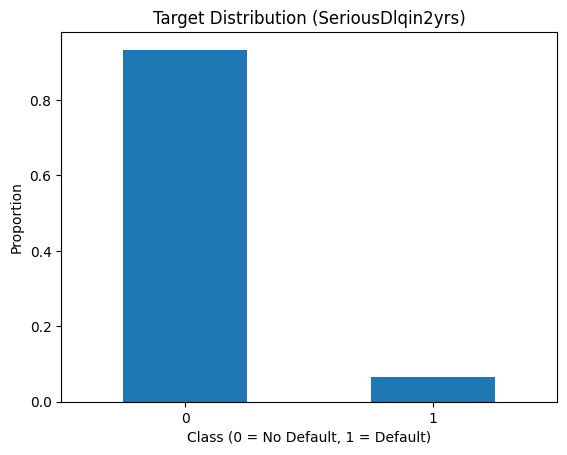

In [97]:
plt.figure()
target_dist.plot(kind='bar')

plt.title('Target Distribution (SeriousDlqin2yrs)')
plt.xlabel('Class (0 = No Default, 1 = Default)')
plt.ylabel('Proportion')

plt.xticks(rotation=0)
plt.show()

Handle Missing Values

1. MonthlyIncome: Impute with median

In [98]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

2. NumberOfDependents: Impute with 0 (or median)

In [99]:
df['NumberOfDependents'].fillna(0, inplace=True)

Crosscheck for null values

In [100]:
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 ID                                      0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
Age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


Feature Engineering

In [101]:
df['TotalPastDue'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                        df['NumberOfTime60-89DaysPastDueNotWorse'] +
                        df['NumberOfTimes90DaysLate'])

In [102]:
df['DebtPerIncome'] = df['DebtRatio'] * df['MonthlyIncome']

Preparing data for Test/Train Split

In [103]:
# Drop ID column for modeling
X = df.drop(columns=['ID', 'SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

Train/Test Split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature scaling

In [105]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle imbalanced data with SMOTE

In [106]:
smote = SMOTE(random_state=42)
X_train_lr, y_train_lr = smote.fit_resample(X_train_scaled, y_train)

In [107]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [108]:
logreg = LogisticRegression(class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

XGBoost Model Training

In [109]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb.fit(X_train_scaled, y_train)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:,1]

Model Evaluation Function

In [110]:
def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)
    
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Evaluate Models

Logistic Regression (SMOTE) Evaluation
Accuracy: 0.7555
Precision: 0.1698
Recall: 0.6838
F1-score: 0.2721
ROC-AUC: 0.7951
PR-AUC: 0.3155


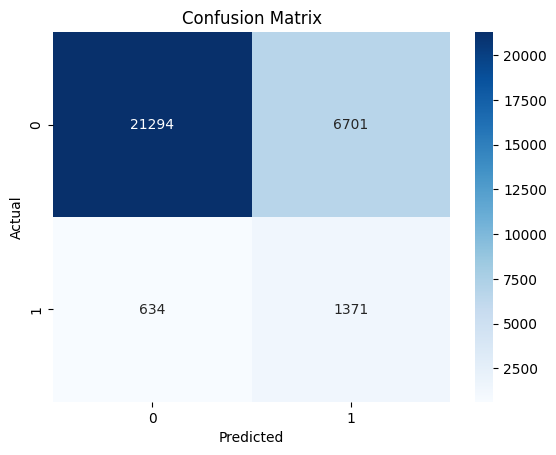

XGBoost (scale_pos_weight) Evaluation
Accuracy: 0.8241
Precision: 0.2325
Recall: 0.7092
F1-score: 0.3502
ROC-AUC: 0.8529
PR-AUC: 0.3834


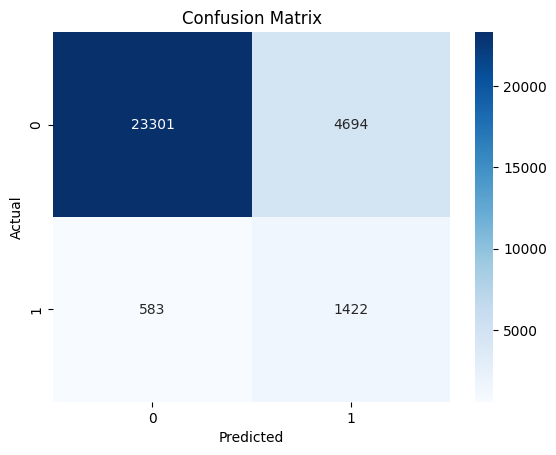

In [111]:
print("Logistic Regression (SMOTE) Evaluation")
evaluate_model(y_test, y_proba_logreg)

print("XGBoost (scale_pos_weight) Evaluation")
evaluate_model(y_test, y_proba_xgb)

SHAP Explainability (XGBoost)

In [112]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)

Summary Plot

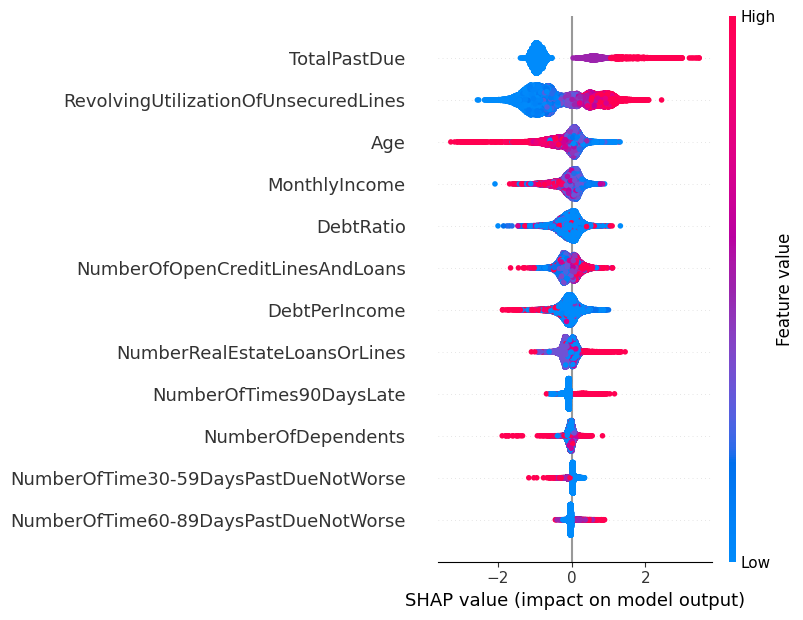

In [113]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

Force plot for first prediction

In [114]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

Model Comparison

In [115]:
roc_logreg = roc_auc_score(y_test, y_proba_logreg)
roc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"ROC-AUC Logistic Regression: {roc_logreg:.4f}")
print(f"ROC-AUC XGBoost: {roc_xgb:.4f}")

if roc_xgb > roc_logreg:
    print("XGBoost performs better.")
else:
    print("Logistic Regression performs better.")

ROC-AUC Logistic Regression: 0.7951
ROC-AUC XGBoost: 0.8529
XGBoost performs better.


Save models and scaler

In [116]:
joblib.dump(logreg, "models/logreg_v1.pkl")
joblib.dump(xgb, "models/xgb_v1.pkl")
joblib.dump(scaler, "models/scaler_v1.pkl")

print("Models and scaler saved successfully!")

Models and scaler saved successfully!
